（A）蒙特卡洛个体级仿真（含超边活跃度 Θ 与 SIP 指示） 与 （B）MMCA（含 Θ 与 SIP 的乘积近似）。

hyperedges m = 4000


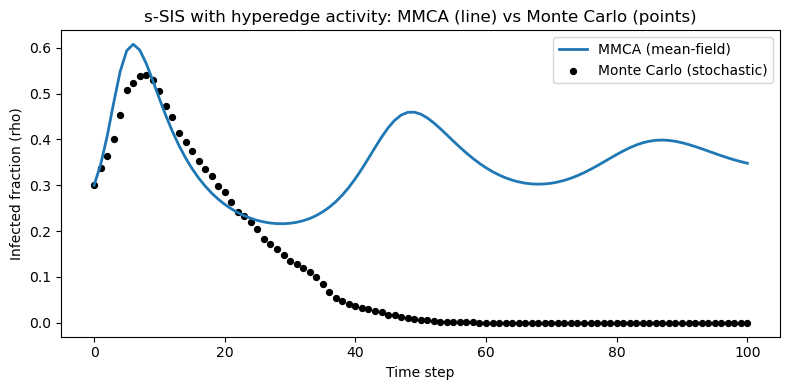

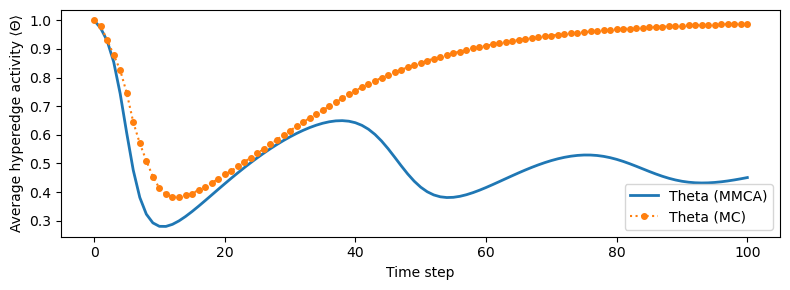

Final infected fraction (MC) = 0.00000, (MMCA) = 0.34789
Final mean Theta (MC) = 0.98859, (MMCA) = 0.45054


In [ ]:
# Retry: s-SIS with Theta for both MC and MMCA (second attempt).
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from collections import defaultdict

def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    # 超边数m
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    # 批量采样候选三元组以减少python开销
    while len(edges_set) < m:
        # 因为要抽取batch_size*d个不同元素，所以True
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        #确保每个三元组有不同的节点；重新采样包含重复项的行
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m: 
                break
            edges_set.add(tuple(row.tolist()))
    # hyperedges格式为numpy数组，类似[[0,1,2],[1,2,3],...]
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

def run_mc_sSIS_with_theta(hyperedges, n, beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                           T=100, init_frac=0.3, seed=None, verbose=False):
    """
    在 d-uniform 超图上模拟带有超边活跃度 (Θ) 的 s-SIS 模型的蒙特卡洛随机动力学。

    参数说明：
    ----------
    hyperedges : np.ndarray
        超边列表，每一行包含 d 个节点编号。
    n : int
        节点总数。
    beta_d : float
        d 阶超边的感染传播概率。
    mu : float
        节点恢复概率。
    eta : float
        超边活跃度 Θ 对感染压力 Φ 的敏感系数。
    gamma : float
        超边活跃度的自然恢复速率。
    T : int
        仿真总步数。
    init_frac : float
        初始感染节点比例。
    seed : int, optional
        随机种子，保证复现实验。
    verbose : bool
        若 True,则每隔若干步打印中间信息。

    返回：
    -----
    rho_ts : np.ndarray
        每个时间步感染节点比例（ρ(t)）的时间序列。
    theta_mean_ts : np.ndarray
        每个时间步平均超边活跃度 ⟨Θ(t)⟩。
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    m = hyperedges.shape[0]  # 超边数量
    states = np.zeros(n, dtype=int)  # 节点状态数组，0=S, 1=I

    # --- 初始化感染节点 ---
    initial_infected = max(1, int(round(init_frac * n)))
    init_nodes = np.random.choice(n, size=initial_infected, replace=False)
    states[init_nodes] = 1

    # --- 初始化所有超边活跃度 Θ_e = 1 ---
    Theta = np.ones(m, dtype=float)

    # --- 记录时间序列 ---
    rho_ts = []
    theta_mean_ts = []
    edges = hyperedges

    for t in range(T):
        # 记录当前感染比例与平均活跃度
        rho_ts.append(states.sum() / n)
        theta_mean_ts.append(Theta.mean())

        # 每条超边对应节点的状态
        states_per_edge = states[edges]
        inf_counts = states_per_edge.sum(axis=1)  # 每条超边的感染节点数

        # ---- 感染传播 ----
        # s-SIS传播条件：若一个超边中有 (d-1) 个感染者，则第 d 个节点以概率 β_d Θ_e 被感染
        candidates = np.where(inf_counts == 2)[0]  # 这里 d=3 ⇒ 恰有 2 感染者的超边才有传播机会
        new_infections = set()

        for idx in candidates:
            nodes_e = edges[idx]  # 当前超边的节点 比如 超边1 [0,1,2]
            node_states = states[nodes_e] # 当前超边的节点状态 比如 [1,1,0]
            sus_pos = np.where(node_states == 0)[0]  # 找出易感者位置
            if sus_pos.size == 0: 
                continue # 若没有易感者，则不传播
            sus_node = nodes_e[sus_pos[0]]  # 唯一的易感节点
            prob = beta_d * Theta[idx]      # 传播概率：β_d × 当前活跃度  ???
            if np.random.rand() < prob:
                new_infections.add(sus_node)

        # ---- 恢复过程 ----
        infected_nodes = np.where(states == 1)[0] # 所有感染节点
        if infected_nodes.size > 0:
            recover_flags = np.random.rand(infected_nodes.size) < mu
            recovered_nodes = infected_nodes[recover_flags]
        else:
            recovered_nodes = np.array([], dtype=int) # 没有感染者，则无需恢复

        # ---- 状态同步更新 ----
        states_next = states.copy()
        if recovered_nodes.size > 0:
            states_next[recovered_nodes] = 0
        for node in new_infections:
            if states_next[node] == 0:
                states_next[node] = 1

        # ---- 更新超边活跃度 Θ ----
        # 定义 Φ_e(t)：若超边内所有节点均感染 ⇒ Φ_e(t)=1，否则=0
        Phi = (inf_counts == 3).astype(float)
        # Θ_e(t+1) = Θ_e(t)*(1 - ηΦ_e(t)) + γ*(1 - Θ_e(t))
        Theta = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        Theta = np.clip(Theta, 0.0, 1.0)  # 保证 Θ∈[0,1]

        states = states_next

        if verbose and (t % 10 == 0):
            print(f"[MC] t={t}, rho={rho_ts[-1]:.4f}, meanTheta={theta_mean_ts[-1]:.4f}")

    # 仿真结束后记录最后一时刻
    rho_ts.append(states.sum() / n)
    theta_mean_ts.append(Theta.mean())

    return np.array(rho_ts), np.array(theta_mean_ts)


def run_mmca_with_theta(hyperedges, n, beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                        T=100, init_frac=0.3, verbose=False):
    """
    在 d-uniform 超图上实现带超边活跃度 (Θ) 的 s-SIS 模型的微观马尔可夫链近似 (MMCA)。

    参数说明：
    ----------
    hyperedges : np.ndarray
        超边列表，每一行包含 d 个节点编号。
    n : int
        节点总数。
    beta_d, mu, eta, gamma : float
        与蒙特卡洛模型中相同的参数。
    T : int
        仿真时间步。
    init_frac : float
        初始感染概率 (用于初始化每个节点的 p_i(0) = init_frac)。
    verbose : bool
        若 True,则打印中间状态。

    返回：
    -----
    rho_ts : np.ndarray
        每个时间步的平均感染概率 ⟨p_i⟩。
    theta_mean_ts : np.ndarray
        每个时间步平均超边活跃度 ⟨Θ⟩。
    """
    m = hyperedges.shape[0]
    edges = hyperedges

    # --- 构建每个节点对应的超边列表（邻接信息） ---
    node_edge_pos = [[] for _ in range(n)]
    for ei in range(m):
        a,b,c = edges[ei]
        node_edge_pos[a].append((ei,0)) # 节点a在超边ei中的位置是0
        node_edge_pos[b].append((ei,1)) # 节点b在超边ei中的位置是1
        node_edge_pos[c].append((ei,2)) # 节点c在超边ei中的位置是2

    # --- 初始化 ---
    p = np.full(n, init_frac, dtype=float)  # 初始感染概率
    Theta = np.ones(m, dtype=float)         # 初始超边活跃度
    rho_ts = []
    theta_mean_ts = []

    # 预存边端点索引，方便矢量化
    edge_i = edges[:,0]; edge_j = edges[:,1]; edge_k = edges[:,2]

    for t in range(T):
        rho_ts.append(p.mean())
        theta_mean_ts.append(Theta.mean())

        # ---- 计算每条超边上“除自身外节点感染概率的乘积” ----
        p_i = p[edge_i]; p_j = p[edge_j]; p_k = p[edge_k]
        # prod = product 乘积
        prod_others_pos0 = p_j * p_k
        prod_others_pos1 = p_i * p_k
        prod_others_pos2 = p_i * p_j

        # ---- 计算每个节点的 q_i(t) ----
        # q_i(t) = ∏_{e∈E_i}(1 - Θ_e β_d ∏_{j∈e\{i\}} p_j(t))
        Q = np.ones(n, dtype=float) 
        for node in range(n):
            prod_val = 1.0
            for (ei, pos) in node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_others_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_others_pos1[ei]
                else:
                    prod_oth = prod_others_pos2[ei]
                term = 1.0 - Theta[ei] * beta_d * prod_oth
                prod_val *= term
            Q[node] = prod_val

        # ---- 更新节点感染概率 ----
        p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p

        # ---- 更新超边活跃度 Θ ----
        Phi_edges = p_i * p_j * p_k    # 连续概率近似 Φ_e(t) = ∏ p_j
        Theta = Theta * (1.0 - eta * Phi_edges) + gamma * (1.0 - Theta)
        Theta = np.clip(Theta, 0.0, 1.0)

        p = p_next

        if verbose and (t % 10 == 0):
            print(f"[MMCA] t={t}, rho={rho_ts[-1]:.4f}, meanTheta={theta_mean_ts[-1]:.4f}")

    rho_ts.append(p.mean())
    theta_mean_ts.append(Theta.mean())
    return np.array(rho_ts), np.array(theta_mean_ts)


# Parameters
n = 2000
kappa = 6.0
beta = 0.3
mu = 0.2
T = 100
init_frac = 0.3
seed = 12345
eta = 1.0
gamma = 0.05

# run
hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=seed, batch_size=3000)
print("hyperedges m =", hyperedges.shape[0])
rho_mc, theta_mc = run_mc_sSIS_with_theta(hyperedges, n, beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                         T=T, init_frac=init_frac, seed=seed, verbose=False)
rho_mmca, theta_mmca = run_mmca_with_theta(hyperedges, n, beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                           T=T, init_frac=init_frac, verbose=False)

# plot
plt.figure(figsize=(8,4))
ts = np.arange(len(rho_mc))
plt.plot(ts, rho_mmca, label='MMCA (mean-field)', linewidth=2)
plt.scatter(ts, rho_mc, label='Monte Carlo (stochastic)', color='black', s=18)
plt.xlabel("Time step")
plt.ylabel("Infected fraction (rho)")
plt.title("s-SIS with hyperedge activity: MMCA (line) vs Monte Carlo (points)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
plt.plot(ts, theta_mmca, label='Theta (MMCA)', linewidth=2)
plt.plot(ts, theta_mc, label='Theta (MC)', linestyle=':', marker='o', markersize=4)
plt.xlabel("Time step")
plt.ylabel("Average hyperedge activity ⟨Θ⟩")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final infected fraction (MC) = {rho_mc[-1]:.5f}, (MMCA) = {rho_mmca[-1]:.5f}")
print(f"Final mean Theta (MC) = {theta_mc[-1]:.5f}, (MMCA) = {theta_mmca[-1]:.5f}")


hyperedges m = 4000


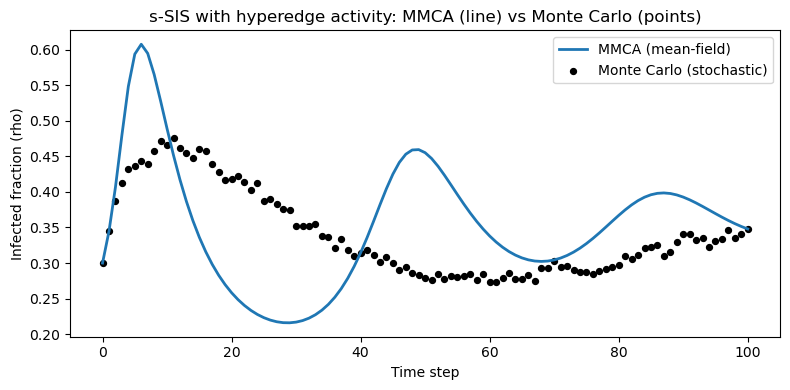

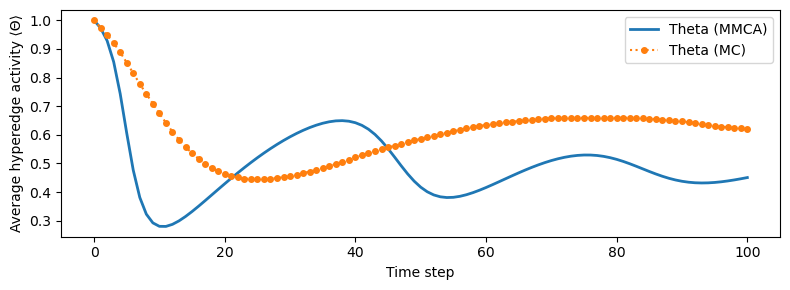

Final infected fraction (MC) = 0.34750, (MMCA) = 0.34789
Final mean Theta (MC) = 0.61959, (MMCA) = 0.45054


In [1]:
#  上个版本的改进版 改进了MC的过程

import numpy as np
import random
import math
import matplotlib.pyplot as plt
from collections import defaultdict

def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    # 超边数m
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    # 批量采样候选三元组以减少python开销
    while len(edges_set) < m:
        # 因为要抽取batch_size*d个不同元素，所以True
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        #确保每个三元组有不同的节点；重新采样包含重复项的行
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m: 
                break
            edges_set.add(tuple(row.tolist()))
    # hyperedges格式为numpy数组，类似[[0,1,2],[1,2,3],...]
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

def run_mc_sSIS_with_theta(hyperedges, n,
                           beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                           T=100, init_frac=0.3, seed=None, verbose=False,
                           p_smooth=0.8):
    """
    Monte-Carlo s-SIS on 3-uniform hypergraph, but infection trials use q_i(t)
    computed from p (EMA-smoothed) and Theta, i.e.
        q_i = 1 - ∏_{e∈E_i}(1 - Θ_e * β_d * ∏_{j∈e\{i}} p_j)

    参数:
      - hyperedges: np.ndarray (m,3)
      - n: 节点数
      - beta_d, mu, eta, gamma: 模型参数
      - T: 步数
      - init_frac: 初始感染比例
      - seed: 随机种子
      - verbose: 是否打印中间信息
      - p_smooth: EMA 平滑系数 α（0..1），用于更新 p:
            p_new = α * p_old + (1-α) * state
          * α=0 -> p 退化为二值 state（原始不平滑 MC）
          * α接近1 -> p 强记忆，更接近 MMCA 的平滑概率（但 α=1 不更新 p，不推荐）
    返回:
      - rho_ts: 感染比例时间序列 (len T+1)
      - theta_mean_ts: 平均 Θ 时间序列 (len T+1)
    """

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    m = hyperedges.shape[0]
    edges = hyperedges

    # ---- 初始化二值状态 ----
    states = np.zeros(n, dtype=int)
    initial_infected = max(1, int(round(init_frac * n)))
    init_nodes = np.random.choice(n, size=initial_infected, replace=False)
    states[init_nodes] = 1

    # ---- 初始化 p (节点感染概率估计) 和 Θ ----
    # p 初始可以用 init_frac 或直接用 states；用 init_frac 更偏平滑起点
    p = np.full(n, init_frac, dtype=float)
    Theta = np.ones(m, dtype=float)

    # ---- 预构建 node -> list of (edge_idx, position) 映射，加速 q 计算 ----
    node_edge_pos = [[] for _ in range(n)]
    for ei in range(m):
        a, b, c = edges[ei]
        node_edge_pos[a].append((ei, 0))
        node_edge_pos[b].append((ei, 1))
        node_edge_pos[c].append((ei, 2))

    # 为矢量化计算，保存每条边的三个节点索引
    edge_i = edges[:, 0]; edge_j = edges[:, 1]; edge_k = edges[:, 2]

    # 记录时序
    rho_ts = []
    theta_mean_ts = []

    # 主循环
    for t in range(T):
        # 1) 记录当前 ß
        rho_ts.append(states.sum() / n)
        theta_mean_ts.append(Theta.mean())

        # 2) 更新 p（EMA）：p <- α*p + (1-α)*state
        #    这个步骤把二值状态平滑为概率估计，使得 q_i 基于连续 p 而非 0/1
        if p_smooth == 0.0:
            # 直接使用当前状态（退化为无平滑）
            p = states.astype(float)
        else:
            alpha = float(p_smooth)
            p = alpha * p + (1.0 - alpha) * states

        # 3) 基于当前 p 与 Θ 计算每个节点的 q_i（矢量化/逐节点混合）
        #    q_i = 1 - ∏_{e∈E_i}(1 - Θ_e * β_d * ∏_{j∈e\{i}} p_j)
        # 先算每条边上“除某个位置之外”的乘积（供不同位置使用）
        p_i = p[edge_i]; p_j = p[edge_j]; p_k = p[edge_k]
        prod_pos0 = p_j * p_k   # 对于位置0节点，其他两个的乘积
        prod_pos1 = p_i * p_k
        prod_pos2 = p_i * p_j

        qi = np.zeros(n, dtype=float)
        # 逐节点累乘其 incident-edge 的项
        for node in range(n):
            prod_val = 1.0
            # 若节点没有 incident edges（理论上不会在稀疏模型中），qi=0
            for (ei, pos) in node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_pos1[ei]
                else:
                    prod_oth = prod_pos2[ei]
                # 项 = 1 - Θ_e * β_d * prod_oth
                term = 1.0 - Theta[ei] * beta_d * prod_oth
                prod_val *= term
            qi[node] = 1.0 - prod_val
        # 数值安全
        qi = np.clip(qi, 0.0, 1.0)

        # 4) 感染试验：对每个易感节点以 qi[i] 进行 Bernoulli 试验
        susceptible_idx = np.where(states == 0)[0]
        new_infections = set()
        for node in susceptible_idx:
            if np.random.rand() < qi[node]:
                new_infections.add(int(node))

        # 5) 恢复试验（与以前一样）
        infected_idx = np.where(states == 1)[0]
        if infected_idx.size > 0:
            recover_flags = np.random.rand(infected_idx.size) < mu
            recovered_nodes = infected_idx[recover_flags]
        else:
            recovered_nodes = np.array([], dtype=int)

        # 6) 同步应用：先恢复，再感染（保持一致的更新顺序）
        states_next = states.copy()
        if recovered_nodes.size > 0:
            states_next[recovered_nodes] = 0
        for node in new_infections:
            if states_next[node] == 0:
                states_next[node] = 1
        states = states_next

        # 7) 更新 Theta（使用 MMCA 风格的 Φ_e = ∏ p_j）
        #    注意这里使用的是更新前的 p（即 p 基于 t 的估计），与 MMCA 风格一致
        Phi_edges = p_i * p_j * p_k
        Theta = Theta * (1.0 - eta * Phi_edges) + gamma * (1.0 - Theta)
        Theta = np.clip(Theta, 0.0, 1.0)

        if verbose and (t % 10 == 0):
            print(f"[MC-q] t={t}, rho={rho_ts[-1]:.4f}, meanTheta={theta_mean_ts[-1]:.4f}")

    # 记录最后时刻
    rho_ts.append(states.sum() / n)
    theta_mean_ts.append(Theta.mean())

    return np.array(rho_ts), np.array(theta_mean_ts)



def run_mmca_with_theta(hyperedges, n, beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                        T=100, init_frac=0.3, verbose=False):
    """
    在 d-uniform 超图上实现带超边活跃度 (Θ) 的 s-SIS 模型的微观马尔可夫链近似 (MMCA)。

    参数说明：
    ----------
    hyperedges : np.ndarray
        超边列表，每一行包含 d 个节点编号。
    n : int
        节点总数。
    beta_d, mu, eta, gamma : float
        与蒙特卡洛模型中相同的参数。
    T : int
        仿真时间步。
    init_frac : float
        初始感染概率 (用于初始化每个节点的 p_i(0) = init_frac)。
    verbose : bool
        若 True,则打印中间状态。

    返回：
    -----
    rho_ts : np.ndarray
        每个时间步的平均感染概率 ⟨p_i⟩。
    theta_mean_ts : np.ndarray
        每个时间步平均超边活跃度 ⟨Θ⟩。
    """
    m = hyperedges.shape[0]
    edges = hyperedges

    # --- 构建每个节点对应的超边列表（邻接信息） ---
    node_edge_pos = [[] for _ in range(n)]
    for ei in range(m):
        a,b,c = edges[ei]
        node_edge_pos[a].append((ei,0)) # 节点a在超边ei中的位置是0
        node_edge_pos[b].append((ei,1)) # 节点b在超边ei中的位置是1
        node_edge_pos[c].append((ei,2)) # 节点c在超边ei中的位置是2

    # --- 初始化 ---
    p = np.full(n, init_frac, dtype=float)  # 初始感染概率
    Theta = np.ones(m, dtype=float)         # 初始超边活跃度
    rho_ts = []
    theta_mean_ts = []

    # 预存边端点索引，方便矢量化
    edge_i = edges[:,0]; edge_j = edges[:,1]; edge_k = edges[:,2]

    for t in range(T):
        rho_ts.append(p.mean())
        theta_mean_ts.append(Theta.mean())

        # ---- 计算每条超边上“除自身外节点感染概率的乘积” ----
        p_i = p[edge_i]; p_j = p[edge_j]; p_k = p[edge_k]
        # prod = product 乘积
        prod_others_pos0 = p_j * p_k
        prod_others_pos1 = p_i * p_k
        prod_others_pos2 = p_i * p_j

        # ---- 计算每个节点的 q_i(t) ----
        # q_i(t) = ∏_{e∈E_i}(1 - Θ_e β_d ∏_{j∈e\{i\}} p_j(t))
        Q = np.ones(n, dtype=float) 
        for node in range(n):
            prod_val = 1.0
            for (ei, pos) in node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_others_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_others_pos1[ei]
                else:
                    prod_oth = prod_others_pos2[ei]
                term = 1.0 - Theta[ei] * beta_d * prod_oth
                prod_val *= term
            Q[node] = prod_val

        # ---- 更新节点感染概率 ----
        p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p

        # ---- 更新超边活跃度 Θ ----
        Phi_edges = p_i * p_j * p_k    # 连续概率近似 Φ_e(t) = ∏ p_j
        Theta = Theta * (1.0 - eta * Phi_edges) + gamma * (1.0 - Theta)
        Theta = np.clip(Theta, 0.0, 1.0)

        p = p_next

        if verbose and (t % 10 == 0):
            print(f"[MMCA] t={t}, rho={rho_ts[-1]:.4f}, meanTheta={theta_mean_ts[-1]:.4f}")

    rho_ts.append(p.mean())
    theta_mean_ts.append(Theta.mean())
    return np.array(rho_ts), np.array(theta_mean_ts)


# Parameters
n = 2000
kappa = 6.0
beta = 0.3
mu = 0.2
T = 100
init_frac = 0.3
seed = 12345
eta = 1.0
gamma = 0.05

# run
hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=seed, batch_size=3000)
print("hyperedges m =", hyperedges.shape[0])
rho_mc, theta_mc = run_mc_sSIS_with_theta(hyperedges, n, beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                         T=T, init_frac=init_frac, seed=seed, verbose=False)
rho_mmca, theta_mmca = run_mmca_with_theta(hyperedges, n, beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                           T=T, init_frac=init_frac, verbose=False)

# plot
plt.figure(figsize=(8,4))
ts = np.arange(len(rho_mc))
plt.plot(ts, rho_mmca, label='MMCA (mean-field)', linewidth=2)
plt.scatter(ts, rho_mc, label='Monte Carlo (stochastic)', color='black', s=18)
plt.xlabel("Time step")
plt.ylabel("Infected fraction (rho)")
plt.title("s-SIS with hyperedge activity: MMCA (line) vs Monte Carlo (points)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
plt.plot(ts, theta_mmca, label='Theta (MMCA)', linewidth=2)
plt.plot(ts, theta_mc, label='Theta (MC)', linestyle=':', marker='o', markersize=4)
plt.xlabel("Time step")
plt.ylabel("Average hyperedge activity ⟨Θ⟩")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final infected fraction (MC) = {rho_mc[-1]:.5f}, (MMCA) = {rho_mmca[-1]:.5f}")
print(f"Final mean Theta (MC) = {theta_mc[-1]:.5f}, (MMCA) = {theta_mmca[-1]:.5f}")
